<a href="https://colab.research.google.com/github/gauthamramesh3110/clinical_data_ml/blob/main/Care_Plan_Suggestor_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
home_path = './drive/MyDrive/patient_data_csv/sythea_1k/'

# Import All Data

In [ ]:
import pandas as pd

def build_unified_timeline(data_dir):
    # 1. Load the raw CSVs (only grabbing the columns we actually need)
    allg_df = pd.read_csv(f"{data_dir}/allergies.csv", usecols=['START', 'PATIENT', 'ENCOUNTER', 'CODE'])
    carep_df = pd.read_csv(f"{data_dir}/careplans.csv", usecols=['START', 'PATIENT', 'ENCOUNTER', 'CODE'])
    cond_df = pd.read_csv(f"{data_dir}/conditions.csv", usecols=['START', 'PATIENT', 'ENCOUNTER', 'CODE'])
    imm_df = pd.read_csv(f"{data_dir}/immunizations.csv", usecols=['DATE', 'PATIENT', 'ENCOUNTER', 'CODE'])
    meds_df = pd.read_csv(f"{data_dir}/medications.csv", usecols=['START', 'PATIENT', 'ENCOUNTER', 'CODE'])
    obs_df = pd.read_csv(f"{data_dir}/observations.csv", usecols=['DATE', 'PATIENT', 'ENCOUNTER', 'CODE'])

    # 2. Standardize Column Names
    # Conditions and Meds use 'START', Obs and Imms use 'DATE'.
    # We rename all of them to 'TIMESTAMP'.
    allg_df = allg_df.rename(columns={'START': 'TIMESTAMP'})
    carep_df = carep_df.rename(columns={'START': 'TIMESTAMP'})
    cond_df = cond_df.rename(columns={'START': 'TIMESTAMP'})
    imm_df = imm_df.rename(columns={'DATE': 'TIMESTAMP'})
    meds_df = meds_df.rename(columns={'START': 'TIMESTAMP'})
    obs_df = obs_df.rename(columns={'DATE': 'TIMESTAMP'})

    # 3. Apply the Unified Vocabulary Prefixes
    # This ensures SNOMED code '123' for a condition isn't confused with RxNorm '123'
    allg_df['EVENT_CODE'] = 'ALLG_' + allg_df['CODE'].astype(str)
    carep_df['EVENT_CODE'] = 'CAREP_' + carep_df['CODE'].astype(str)
    cond_df['EVENT_CODE'] = 'COND_' + cond_df['CODE'].astype(str)
    imm_df['EVENT_CODE'] = 'IMM_' + imm_df['CODE'].astype(str)
    meds_df['EVENT_CODE'] = 'MED_' + meds_df['CODE'].astype(str)
    obs_df['EVENT_CODE'] = 'OBS_' + obs_df['CODE'].astype(str)

    # Drop the old un-prefixed CODE columns to keep things clean
    allg_df = allg_df.drop(columns=['CODE'])
    carep_df = carep_df.drop(columns=['CODE'])
    cond_df = cond_df.drop(columns=['CODE'])
    imm_df = imm_df.drop(columns=['CODE'])
    meds_df = meds_df.drop(columns=['CODE'])
    obs_df = obs_df.drop(columns=['CODE'])

    # 4. Combine Everything Together
    # Concatenate all the dataframes vertically
    unified_events = pd.concat([allg_df, carep_df, cond_df, imm_df, meds_df, obs_df], ignore_index=True)

    # 5. The Magic Step: Sort the Timeline
    # We sort first by Patient, then by the exact Timestamp of the event
    unified_events = unified_events.sort_values(by=['PATIENT', 'TIMESTAMP'])

    return unified_events

# Execute the unification
unified_df = build_unified_timeline(home_path)
display(unified_df)

,TIMESTAMP,PATIENT,ENCOUNTER,EVENT_CODE
22859,2010-11-09T15:06:37Z,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,IMM_140
261946,2010-11-09T15:06:37Z,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_8302-2
261947,2010-11-09T15:06:37Z,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_72514-3
261948,2010-11-09T15:06:37Z,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_29463-7
261949,2010-11-09T15:06:37Z,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_39156-5
...,...,...,...,...
283206,2019-11-18T09:02:32Z,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8462-4
283207,2019-11-18T09:02:32Z,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8480-6
283208,2019-11-18T09:02:32Z,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8867-4
283209,2019-11-18T09:02:32Z,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_9279-1


In [ ]:
import pandas as pd

def add_encounter_context(unified_df, encounters_path):
    # 1. Load the Encounters
    encounters_df = pd.read_csv(encounters_path, usecols=['Id', 'START'])
    encounters_df = encounters_df.rename(columns={'Id': 'ENCOUNTER', 'START': 'ENCOUNTER_TIME'})

    # 2. Merge them together
    merged_df = pd.merge(unified_df, encounters_df, on='ENCOUNTER', how='left')

    # 3. Convert BOTH time columns to Datetime objects before math
    merged_df['ENCOUNTER_TIME'] = pd.to_datetime(merged_df['ENCOUNTER_TIME'], format='mixed', utc=True)
    merged_df['TIMESTAMP'] = pd.to_datetime(merged_df['TIMESTAMP'], format='mixed', utc=True)

    # 4. THE FIX: Create the Anchor Time using fillna()
    # This says: "Use ENCOUNTER_TIME. If it is NaT (Not a Time), use TIMESTAMP instead."
    merged_df['ANCHOR_TIME'] = merged_df['ENCOUNTER_TIME'].fillna(merged_df['TIMESTAMP'])

    # 5. Calculate the Time Gap using the new Anchor
    merged_df['DAYS_SINCE_START'] = merged_df.groupby('PATIENT')['ANCHOR_TIME'].transform(
        lambda x: (x - x.min()).dt.days
    )

    # 6. Clean up and Sort
    # We drop the old time columns to keep the dataframe light, keeping only the final anchor
    merged_df = merged_df.drop(columns=['ENCOUNTER_TIME', 'TIMESTAMP'])
    final_df = merged_df.sort_values(by=['PATIENT', 'ANCHOR_TIME'])

    return final_df

# Run the merge
context_df = add_encounter_context(unified_df, f"{home_path}encounters.csv")

In [ ]:
display(context_df)

,PATIENT,ENCOUNTER,EVENT_CODE,ANCHOR_TIME,DAYS_SINCE_START
0,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,IMM_140,2010-11-09 15:06:37+00:00,0
1,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_8302-2,2010-11-09 15:06:37+00:00,0
2,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_72514-3,2010-11-09 15:06:37+00:00,0
3,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_29463-7,2010-11-09 15:06:37+00:00,0
4,00185faa-2760-4218-9bf5-db301acf8274,6b5bfe89-1c58-42e8-87c4-847b542d5f0b,OBS_39156-5,2010-11-09 15:06:37+00:00,0
...,...,...,...,...,...
370615,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8462-4,2019-11-18 09:02:32+00:00,1253
370616,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8480-6,2019-11-18 09:02:32+00:00,1253
370617,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_8867-4,2019-11-18 09:02:32+00:00,1253
370618,ffcfa457-00c2-4405-9837-ac2781549c7e,4dfd2398-8829-4fdf-a7ef-7f7e96766836,OBS_9279-1,2019-11-18 09:02:32+00:00,1253


In [ ]:
import pandas as pd

class MultimodalTokenizer:
    def __init__(self, careplan_prefix='CAREP_'):
        # Reserve 0 for padding and 1 for unknown medical codes
        self.token_vocab = {"<PAD>": 0, "<UNK>": 1}
        self.target_vocab = {}
        self.careplan_prefix = careplan_prefix

    def build_dataset(self, unified_df):
        """
        Extracts the sequence and the target directly from the unified timeline.
        The target is the LATEST care plan.
        """
        dataset_samples = []
        token_idx = len(self.token_vocab)
        target_idx = 0

        # Group the timeline by patient
        grouped_events = unified_df.groupby('PATIENT')

        for patient_id, patient_events in grouped_events:
            # 1. Isolate all care plans in the patient's history
            is_careplan = patient_events['EVENT_CODE'].str.startswith(self.careplan_prefix)
            careplan_events = patient_events[is_careplan]

            # If the patient has no care plans, we skip them
            if careplan_events.empty:
                continue

            # 2. Extract the LATEST care plan (the very last row)
            target_event = careplan_events.iloc[-1]
            target_code = target_event['EVENT_CODE']
            target_date = target_event['ANCHOR_TIME']

            # 3. Filter the History (Prevent Data Leakage)
            # We want all events that happened ON or BEFORE the target date.
            # CRITICAL: We must explicitly remove the target care plan itself from the history
            # so the model doesn't "see" the answer right before making its prediction.
            valid_history = patient_events[
                (patient_events['ANCHOR_TIME'] <= target_date) &
                (patient_events.index != target_event.name)
            ]

            # If removing the target leaves the patient with no history, skip them
            if valid_history.empty:
                continue

            # 4. Clean and Store the Target Label
            # Strip the "CPLAN_" prefix to keep the target labels clean
            clean_target = target_code.replace(self.careplan_prefix, '')
            if clean_target not in self.target_vocab:
                self.target_vocab[clean_target] = target_idx
                target_idx += 1

            # 5. Tokenize the Sequence and Extract Time Deltas
            encoded_tokens = []
            times = []

            for _, event in valid_history.iterrows():
                code = event['EVENT_CODE']

                # Add new medical codes (Conditions, Meds, older Care Plans, etc.)
                if code not in self.token_vocab:
                    self.token_vocab[code] = token_idx
                    token_idx += 1

                encoded_tokens.append(self.token_vocab[code])
                times.append(float(event['DAYS_SINCE_START']))

            # 6. Append the formatted sample
            # Notice we do not include the time for the target here, just the label ID
            dataset_samples.append({
                'tokens': encoded_tokens,
                'times': times,
                'target': self.target_vocab[clean_target]
            })

        return dataset_samples

# --- Execution ---
# Initialize the tokenizer (adjust the prefix if you used something different)
tokenizer = MultimodalTokenizer(careplan_prefix='CAREP_')

# Build the dataset using ONLY the unified dataframe
encoded_patient_samples = tokenizer.build_dataset(unified_df=context_df)

vocab_size = len(tokenizer.token_vocab)
num_careplans = len(tokenizer.target_vocab)

print(f"Total Patients Processed: {len(encoded_patient_samples)}")
print(f"Total Unique Tokens (Vocab Size): {vocab_size}")
print(f"Total Unique Care Plans (Classes): {num_careplans}")

Total Patients Processed: 1046
Total Unique Tokens (Vocab Size): 440
Total Unique Care Plans (Classes): 28


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TimeAwareEHRDataset(Dataset):
    def __init__(self, patient_samples):
        """
        patient_samples is a list of dicts:
        [{'tokens': [...], 'times': [...], 'target': int}, ...]
        """
        self.samples = patient_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def time_aware_collate_fn(batch):
    """
    Dynamically pads the varying sequence lengths in a batch so they can be processed
    as a single matrix, and generates the Attention Mask.
    """
    # Extract lists of tensors from the batch
    tokens = [torch.tensor(item['tokens'], dtype=torch.long) for item in batch]
    times = [torch.tensor(item['times'], dtype=torch.float) for item in batch]
    targets = torch.tensor([item['target'] for item in batch], dtype=torch.long)

    # 1. Pad the Medical Codes (using 0 as the PAD_TOKEN)
    padded_tokens = pad_sequence(tokens, batch_first=True, padding_value=0)

    # 2. Pad the Time Deltas (using 0.0, the model ignores these via the mask anyway)
    padded_times = pad_sequence(times, batch_first=True, padding_value=0.0)

    # 3. Create the Boolean Attention Mask
    # True means "Ignore this token because it is fake padding"
    pad_mask = (padded_tokens == 0)

    return padded_tokens, padded_times, targets, pad_mask

# Initialize your dataset and loader
dataset = TimeAwareEHRDataset(encoded_patient_samples)

In [ ]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

# Assuming 'dataset' is your initialized TimeAwareEHRDataset
total_patients = len(dataset)
train_size = int(0.8 * total_patients)
val_size = total_patients - train_size

# Randomly split the patients (ensuring a patient isn't in both sets)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create TWO DataLoaders now.
# Crucially, shuffle=False for the validation set to keep evaluation consistent.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=time_aware_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=time_aware_collate_fn)

# Define the Model

In [ ]:
import torch
import torch.nn as nn
import math

class TimeAwareClinicalTransformer(nn.Module):
    def __init__(self, vocab_size, num_careplans, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super(TimeAwareClinicalTransformer, self).__init__()

        self.d_model = d_model

        # 1. The Categorical Embedding (for Medical Codes)
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # 2. The Continuous Time Embedding (Replaces VisitEmbedding)
        # We use a Linear layer to project a single scalar (days) into a d_model vector
        self.time_embedding = nn.Linear(1, d_model)

        self.embedding_dropout = nn.Dropout(p=dropout)

        # 3. Transformer Stack
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # 4. Classification Head
        self.fc_out = nn.Linear(d_model, num_careplans)

    def forward(self, tokens, time_deltas, pad_mask=None):
        # 1. Embeddings
        x_tokens = self.token_embedding(tokens) * math.sqrt(self.d_model)
        time_deltas = time_deltas.unsqueeze(-1).float()
        x_time = self.time_embedding(time_deltas)

        x = x_tokens + x_time
        x = self.embedding_dropout(x)

        # 2. Transformer
        output = self.transformer_encoder(x, src_key_padding_mask=pad_mask)

        # pad_mask is True for padding.
        # By using ~, we flip it so True means a REAL token.
        # Summing it gives us the exact sequence length for each patient in the batch.

        if pad_mask is None:
            # If no mask was provided, there is no padding.
            # We can safely just grab the absolute last token in the matrix.
            last_token_output = output[:, -1, :]
        else:
            # If a mask IS provided, count the real tokens to find the true end
            # (~pad_mask) flips True/False so we can count the valid tokens
            actual_lengths = (~pad_mask).sum(dim=1)
            last_token_indices = actual_lengths - 1

            # Extract the precise token for each patient using advanced indexing
            last_token_output = output[torch.arange(output.size(0)), last_token_indices, :]

        # ------------------------------------------------

        # 3. Predict
        logits = self.fc_out(last_token_output)

        return logits

# Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Setup Device (Use GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# 2. Initialize Model, Loss Function, and Optimizer
# (Assuming vocab_size=5000 and num_careplans=50 from your tokenizer)
model = TimeAwareClinicalTransformer(
    vocab_size=5000,
    num_careplans=50,
    d_model=64,
    nhead=2,
    dropout=0.3,
    num_layers=1
).to(device)

# CrossEntropyLoss automatically applies Softmax, which is why we didn't put it in the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 3. The Training Epoch Loop
num_epochs = 100
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth'

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Iterate through the batches provided by the DataLoader
    for batch_tokens, batch_times, batch_targets, batch_mask in train_loader:

        # Move all data to the GPU/CPU
        batch_tokens = batch_tokens.to(device)
        batch_times = batch_times.to(device)
        batch_times = torch.log1p(batch_times)
        batch_targets = batch_targets.to(device)
        batch_mask = batch_mask.to(device)

        # A. Zero the gradients from the previous step
        optimizer.zero_grad()

        # B. Forward Pass: Ask the model to make predictions
        logits = model(
            tokens=batch_tokens,
            time_deltas=batch_times,
            pad_mask=batch_mask
        )

        # C. Calculate the Loss (how wrong the model was)
        loss = criterion(logits, batch_targets)

        # D. Backward Pass: Calculate the gradients
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # E. Update the weights
        optimizer.step()

        # --- Tracking Metrics ---
        total_loss += loss.item() * batch_tokens.size(0)

        # Get the highest probability prediction (argmax)
        _, predicted_classes = torch.max(logits, dim=1)
        correct_predictions += (predicted_classes == batch_targets).sum().item()
        total_samples += batch_targets.size(0)

    # ==========================
    #      VALIDATION PHASE
    # ==========================
    model.eval() # Turn off Dropout and stabilize BatchNorm
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # torch.no_grad() is critical. It turns off the backpropagation engine,
    # saving massive amounts of memory and preventing the model from learning.
    with torch.no_grad():
        for val_tokens, val_times, val_targets, val_mask in val_loader:

            val_tokens = val_tokens.to(device)
            val_times = torch.log1p(val_times).to(device) # Keep the log scale!
            val_targets = val_targets.to(device)
            val_mask = val_mask.to(device)

            # Forward pass only
            val_logits = model(val_tokens, val_times, val_mask)

            # Calculate metrics
            loss = criterion(val_logits, val_targets)
            val_loss += loss.item() * val_tokens.size(0)

            _, predicted = torch.max(val_logits, dim=1)
            val_correct += (predicted == val_targets).sum().item()
            val_total += val_targets.size(0)

    # Calculate average loss and accuracy for this epoch
    epoch_loss = total_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100

    # Calculate final epoch metrics
    avg_val_loss = val_loss / val_total
    avg_val_acc = (val_correct / val_total) * 100

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {epoch_acc:.2f}% | Val Acc: {avg_val_acc:.2f}% | Val Loss: {avg_val_loss:.4f}")

    # Save the best model weights
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"--> Saved best model with Val Loss: {best_val_loss:.4f} to {save_path}")

print("Training Complete!")

Training on: cuda
Epoch [1/100] | Train Acc: 15.43% | Val Acc: 24.76% | Val Loss: 3.0399
--> Saved best model with Val Loss: 3.0399 to /content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth
Epoch [2/100] | Train Acc: 28.35% | Val Acc: 38.57% | Val Loss: 2.6397
--> Saved best model with Val Loss: 2.6397 to /content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth
Epoch [3/100] | Train Acc: 39.23% | Val Acc: 46.67% | Val Loss: 2.3754
--> Saved best model with Val Loss: 2.3754 to /content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth
Epoch [4/100] | Train Acc: 46.77% | Val Acc: 52.38% | Val Loss: 2.1674
--> Saved best model with Val Loss: 2.1674 to /content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth
Epoch [5/100] | Train Acc: 51.20% | Val Acc: 51.90% | Val Loss: 2.0043
--> Saved best model with Val Loss: 2.0043 to /content/drive/MyDrive/patient_data_csv/care_plan_suggestor_transformer.pth
Epoch [6/100] | T

In [ ]:
import torch
from sklearn.metrics import classification_report
import numpy as np

def evaluate_transformer(model, dataloader, device, target_vocab):
    model.eval()

    # Tracking metrics
    top1_correct = 0
    top3_correct = 0
    top5_correct = 0
    total_samples = 0

    # For the classification report
    all_predictions = []
    all_targets = []

    # Reverse the vocabulary dictionary so we can print the actual string names
    idx_to_class = {v: k for k, v in target_vocab.items()}

    with torch.no_grad():
        for tokens, times, targets, mask in dataloader:

            # Move to device and log-scale the times
            tokens = tokens.to(device)
            times = torch.log1p(times).to(device)
            targets = targets.to(device)
            mask = mask.to(device)

            # Forward pass
            logits = model(tokens, times, mask)

            # --- Top-K Calculations ---
            # Get the top 5 predicted classes and their indices
            _, top5_preds = torch.topk(logits, k=5, dim=1)

            # Check if the true target is in the Top 1, Top 3, or Top 5 predictions
            for i in range(targets.size(0)):
                true_target = targets[i].item()
                patient_top5 = top5_preds[i].tolist()

                if true_target == patient_top5[0]:
                    top1_correct += 1
                if true_target in patient_top5[:3]:
                    top3_correct += 1
                if true_target in patient_top5:
                    top5_correct += 1

                total_samples += 1

                # Store Top-1 for the sklearn report
                all_predictions.append(patient_top5[0])
                all_targets.append(true_target)

    # --- Calculate Percentages ---
    top1_acc = (top1_correct / total_samples) * 100
    top3_acc = (top3_correct / total_samples) * 100
    top5_acc = (top5_correct / total_samples) * 100

    print("========================================")
    print("      FINAL CLINICAL EVALUATION         ")
    print("========================================")
    print(f"Top-1 Accuracy: {top1_acc:.2f}%")
    print(f"Top-3 Accuracy: {top3_acc:.2f}%")
    print(f"Top-5 Accuracy: {top5_acc:.2f}%")
    print("========================================\n")

    all_labels = list(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in all_labels]

    # 2. Pass the labels parameter to force sklearn to evaluate every class
    report = classification_report(
        all_targets,
        all_predictions,
        labels=all_labels,         # <--- THE FIX
        target_names=target_names,
        zero_division=0            # Keeps rare classes from throwing warnings
    )

    print(report)
    return all_targets, all_predictions, target_names

# --- Execution ---
# Pass in your trained model, the validation loader, your device, and the target dictionary from tokenizer
all_targets, all_predictions, target_names = evaluate_transformer(
    model,
    val_loader,
    device,
    tokenizer.target_vocab
)

      FINAL CLINICAL EVALUATION         
Top-1 Accuracy: 69.52%
Top-3 Accuracy: 90.95%
Top-5 Accuracy: 97.14%

                 precision    recall  f1-score   support

       53950000       0.70      0.90      0.79        52
      443402002       1.00      0.27      0.43        11
      133901003       0.00      0.00      0.00         5
      134435003       1.00      0.91      0.95        23
      408869004       0.86      0.67      0.75         9
781831000000109       0.00      0.00      0.00         1
      385691007       0.65      0.79      0.71        14
      736353004       1.00      1.00      1.00         8
      225358003       1.00      0.05      0.09        21
      736285004       1.00      0.83      0.91         6
      735984001       1.00      1.00      1.00         2
      698360004       0.47      0.78      0.58         9
      736252007       0.29      1.00      0.44         2
       47387005       1.00      0.86      0.92         7
      737434004       0.00      0

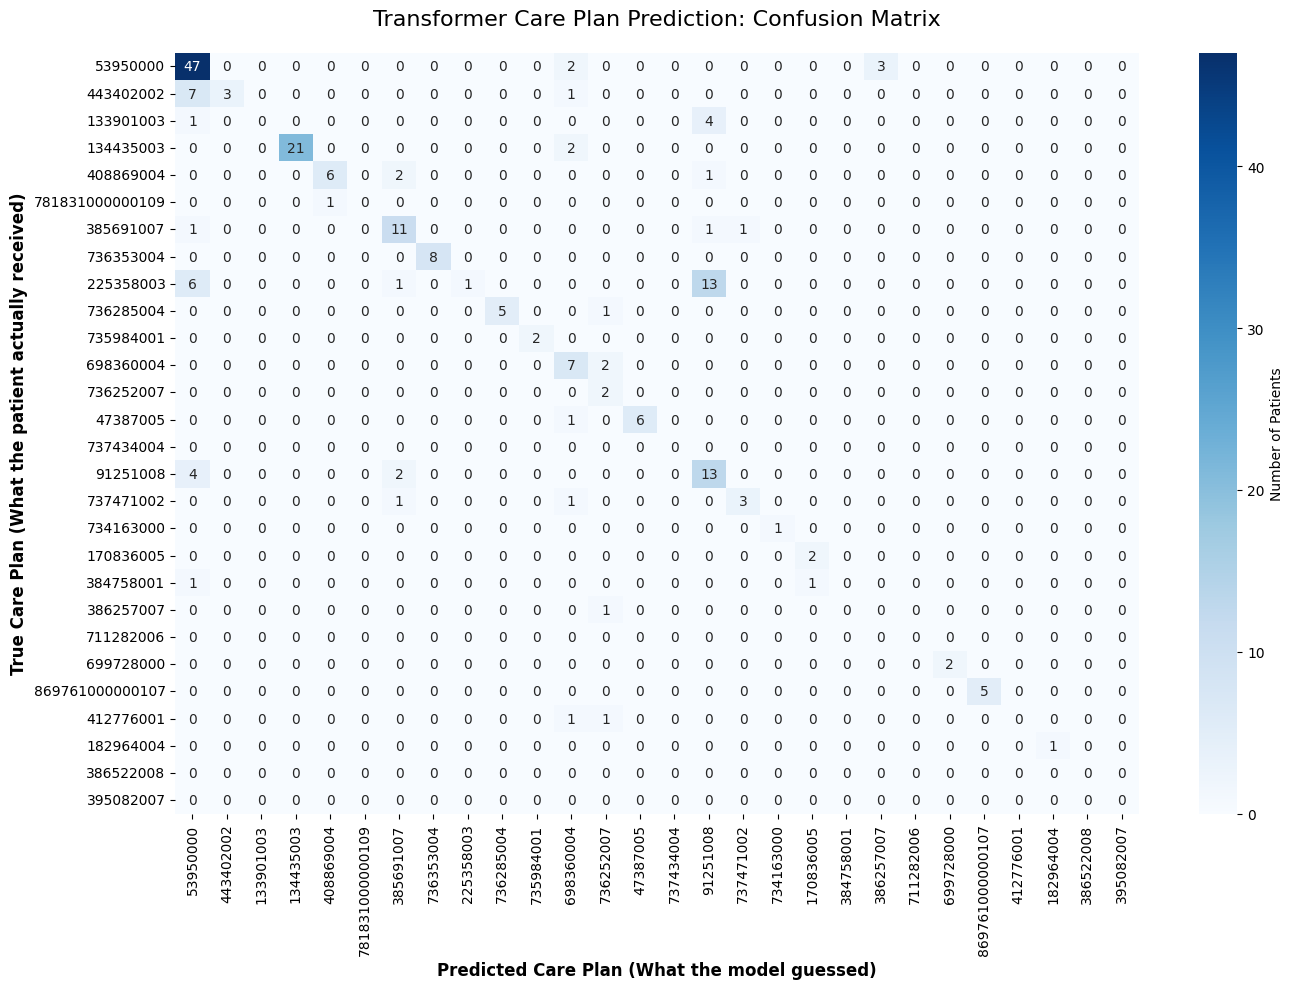

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_targets, all_predictions, target_names):
    """
    Generates a heatmap of the confusion matrix.
    Ensure all_targets and all_predictions are the lists generated in the evaluation loop.
    """
    # 1. Generate the raw confusion matrix
    # We use the labels parameter to ensure all 28 classes are plotted, even the rare ones
    all_labels = range(len(target_names))
    cm = confusion_matrix(all_targets, all_predictions, labels=all_labels)

    # 2. Set up the Matplotlib figure
    # A 14x10 figure is usually large enough to read 28 overlapping axis labels
    plt.figure(figsize=(14, 10))

    # 3. Create the Seaborn Heatmap
    # annot=True puts the actual numbers inside the boxes
    # cmap="Blues" provides a clean, professional color gradient
    # fmt="d" ensures the numbers are formatted as whole integers
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        cbar_kws={'label': 'Number of Patients'}
    )

    # 4. Format the plot for readability
    plt.title("Transformer Care Plan Prediction: Confusion Matrix", fontsize=16, pad=20)
    plt.ylabel('True Care Plan (What the patient actually received)', fontsize=12, weight='bold')
    plt.xlabel('Predicted Care Plan (What the model guessed)', fontsize=12, weight='bold')

    # Rotate the x-axis labels so they don't overlap
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # Adjust layout to prevent the long care plan codes from being cut off
    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_confusion_matrix(all_targets, all_predictions, target_names)

# End-To-End

In [ ]:
import pandas as pd

# Load the careplans data, selecting only CODE and DESCRIPTION
careplan_desc_df = pd.read_csv(f"{home_path}careplans.csv", usecols=['CODE', 'DESCRIPTION'])

# Drop duplicates to get unique code-description pairs
careplan_desc_df = careplan_desc_df.drop_duplicates(subset=['CODE'])

# Convert to a dictionary mapping CODE (as string) to DESCRIPTION
careplan_mapping = dict(zip(careplan_desc_df['CODE'].astype(str), careplan_desc_df['DESCRIPTION']))

# Display a few items to verify
print("Sample care plan mappings:")
for code, desc in list(careplan_mapping.items())[:5]:
    print(f"{code}: {desc}")


Sample care plan mappings:
53950000: Respiratory therapy
225358003: Wound care
91251008: Physical therapy procedure
869761000000107: Urinary tract infection care
385691007: Fracture care


## Build End-to-End Pipeline Function

### Subtask:
Define a function that extracts a patient's clinical history, tokenizes it, and uses the trained model to predict their next Care Plan.


**Reasoning**:
I will define a function that extracts a patient's clinical history from the context dataframe, tokenizes it, and uses the trained transformer model to predict their next Care Plan.



In [ ]:
import torch

def predict_next_careplan(patient_id, model, tokenizer, context_df, device, careplan_mapping):
    # 1. Filter the context dataframe for the specific patient
    patient_events = context_df[context_df['PATIENT'] == patient_id]
    if patient_events.empty:
        return None

    # 2. Isolate care plan events to find the target date
    is_careplan = patient_events['EVENT_CODE'].str.startswith(tokenizer.careplan_prefix)
    careplan_events = patient_events[is_careplan]

    if careplan_events.empty:
        return None

    # Extract the LATEST care plan (the very last row)
    target_event = careplan_events.iloc[-1]
    target_date = target_event['ANCHOR_TIME']

    # 3. Filter the History (Prevent Data Leakage)
    valid_history = patient_events[
        (patient_events['ANCHOR_TIME'] <= target_date) &
        (patient_events.index != target_event.name)
    ]

    if valid_history.empty:
        return None

    # 4. Tokenize the Sequence and Extract Time Deltas
    encoded_tokens = []
    times = []

    for _, event in valid_history.iterrows():
        code = event['EVENT_CODE']
        # Use <UNK> (ID 1) if the code wasn't in the training vocab
        token_id = tokenizer.token_vocab.get(code, 1)
        encoded_tokens.append(token_id)
        times.append(float(event['DAYS_SINCE_START']))

    # 5. Convert to PyTorch Tensors and prepare for the model
    # Add a batch dimension of 1 using unsqueeze(0)
    tokens_tensor = torch.tensor(encoded_tokens, dtype=torch.long).unsqueeze(0).to(device)
    times_tensor = torch.tensor(times, dtype=torch.float).unsqueeze(0)
    times_tensor = torch.log1p(times_tensor).to(device) # Apply log scaling to time

    # Create a boolean mask of False (no padding needed for a single sequence)
    mask_tensor = torch.zeros_like(tokens_tensor, dtype=torch.bool).to(device)

    # 6. Make the Prediction
    model.eval()
    with torch.no_grad():
        logits = model(tokens_tensor, times_tensor, mask_tensor)
        # Get the index of the highest probability
        _, predicted_idx = torch.max(logits, dim=1)
        predicted_idx = predicted_idx.item()

    # 7. Reverse the vocab mapping to get the original code
    idx_to_class = {v: k for k, v in tokenizer.target_vocab.items()}
    predicted_code = idx_to_class[predicted_idx]

    # 8. Get the description
    predicted_desc = careplan_mapping.get(predicted_code, "Unknown Care Plan Description")

    return {
        'predicted_code': predicted_code,
        'predicted_description': predicted_desc
    }


## Demonstrate on Validation Set



In [ ]:
import random

def demonstrate_pipeline(context_df, model, tokenizer, device, careplan_mapping, num_samples=10):
    # 1. Get unique patient IDs and shuffle them
    unique_patients = context_df['PATIENT'].unique().tolist()
    random.shuffle(unique_patients)

    count = 0
    print(f"--- Demonstrating Predictions on {num_samples} Random Patients ---\n")

    # 2. Iterate through random patients
    for patient_id in unique_patients:
        # Find true care plan
        patient_events = context_df[context_df['PATIENT'] == patient_id]
        is_careplan = patient_events['EVENT_CODE'].str.startswith(tokenizer.careplan_prefix)
        careplan_events = patient_events[is_careplan]

        if careplan_events.empty:
            continue

        true_event = careplan_events.iloc[-1]
        true_code_raw = true_event['EVENT_CODE']
        true_code = true_code_raw.replace(tokenizer.careplan_prefix, '')
        true_desc = careplan_mapping.get(true_code, "Unknown Care Plan Description")

        # 3. Predict using the pipeline
        prediction = predict_next_careplan(patient_id, model, tokenizer, context_df, device, careplan_mapping)

        # 4. Print and check if we have enough samples
        if prediction is not None:
            pred_desc = prediction['predicted_description']

            print(f"Patient ID: {patient_id}")
            print(f"  True Care Plan:      {true_desc}")
            print(f"  Predicted Care Plan: {pred_desc}")
            print("-" * 60)

            count += 1
            if count >= num_samples:
                break

# 5. Execute the demonstration
demonstrate_pipeline(context_df, model, tokenizer, device, careplan_mapping, num_samples=10)

--- Demonstrating Predictions on 10 Random Patients ---

Patient ID: 9b50f7b9-c67c-4044-aad0-594ee95b0c29
  True Care Plan:      Self-care interventions (procedure)
  Predicted Care Plan: Respiratory therapy
------------------------------------------------------------
Patient ID: f1728f28-ef0c-4342-9216-a4a4e8375961
  True Care Plan:      Routine antenatal care
  Predicted Care Plan: Routine antenatal care
------------------------------------------------------------
Patient ID: 2f76733b-933c-4cc5-aea2-53799158c8cc
  True Care Plan:      Burn care
  Predicted Care Plan: Physical therapy procedure
------------------------------------------------------------
Patient ID: 92c8d9dc-2430-4b35-8fa8-63bf6913737b
  True Care Plan:      Diabetes self management plan
  Predicted Care Plan: Diabetes self management plan
------------------------------------------------------------
Patient ID: e4945ad4-5f21-460f-a420-98a32ef61d3d
  True Care Plan:      Respiratory therapy
  Predicted Care Plan: Respi

# Interpretability


In [ ]:
!pip install captum

**Reasoning**:
Import the IntegratedGradients class from captum.attr.



In [ ]:
from captum.attr import IntegratedGradients

## Create Model Wrapper

### Subtask:
Define a custom PyTorch model wrapper to intercept the forward pass at the embedding layer.


**Reasoning**:
Create a custom PyTorch model wrapper to intercept the forward pass at the embedding layer.



In [ ]:
import torch
import torch.nn as nn
import math

class EmbeddingWrapper(nn.Module):
    def __init__(self, model):
        super(EmbeddingWrapper, self).__init__()
        self.model = model

    def forward(self, token_embeddings, time_deltas, pad_mask=None):
        # Multiply token embeddings by sqrt(d_model)
        x_tokens = token_embeddings * math.sqrt(self.model.d_model)

        # Process time deltas
        time_deltas = time_deltas.unsqueeze(-1).float()
        x_time = self.model.time_embedding(time_deltas)

        # Combine embeddings and apply dropout
        x = x_tokens + x_time
        x = self.model.embedding_dropout(x)

        # Pass through the transformer encoder
        output = self.model.transformer_encoder(x, src_key_padding_mask=pad_mask)

        # Dynamic Last Token Extraction
        if pad_mask is None:
            last_token_output = output[:, -1, :]
        else:
            actual_lengths = (~pad_mask).sum(dim=1)
            last_token_indices = actual_lengths - 1
            last_token_output = output[torch.arange(output.size(0)), last_token_indices, :]

        # Predict logits
        logits = self.model.fc_out(last_token_output)
        return logits


## Compute Attributions


In [ ]:
import torch

# 1. Select a sample patient from the val_dataset
sample_idx = 0
sample_patient = val_dataset[sample_idx]
tokens = sample_patient['tokens']
times = sample_patient['times']
target = sample_patient['target']

# 2. Convert to tensors, add batch dimension, and prepare inputs
tokens_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
times_tensor = torch.tensor(times, dtype=torch.float).unsqueeze(0)
times_tensor = torch.log1p(times_tensor).to(device)
mask_tensor = (tokens_tensor == 0).to(device)

# 3. Instantiate the wrapper
wrapper = EmbeddingWrapper(model)

# 4. Initialize IntegratedGradients
ig = IntegratedGradients(wrapper)

# 5. Compute continuous token embeddings to use as inputs
# We don't use no_grad here because Captum needs to compute gradients w.r.t these embeddings
token_embeddings = model.token_embedding(tokens_tensor)

# 6. Create a baseline (zeros with the exact same shape)
baseline = torch.zeros_like(token_embeddings).to(device)

# 7. Compute attributions
attributions, delta = ig.attribute(
    inputs=token_embeddings,
    baselines=baseline,
    target=target,
    additional_forward_args=(times_tensor, mask_tensor),
    return_convergence_delta=True
)

# 8. Sum attributions across the embedding dimension to get a single score per token
token_attributions = attributions.sum(dim=-1).squeeze(0)

print(f"Target Class: {target}")
print(f"Number of tokens: {len(tokens)}")
print("Attribution scores per token:")
print(token_attributions)


Target Class: 13
Number of tokens: 123
Attribution scores per token:
tensor([-1.0995e-02,  8.9565e-05,  3.6062e-02,  3.2111e-02, -8.4494e-03,
        -1.2862e-02,  1.8199e-03,  9.7251e-03, -1.2732e-03,  2.6771e-02,
        -1.2634e-02, -1.1784e-02,  3.1336e-01,  1.3802e-02,  1.1956e-01,
         1.3729e-01,  4.1687e-01,  1.5449e-03, -2.7056e-03, -2.4739e-03,
         1.4551e-03,  7.4763e-04, -1.4515e-03, -1.4811e-03,  4.2726e-04,
        -8.2522e-03,  1.6603e-03,  7.8933e-03,  3.0756e-02,  6.7180e-04,
        -2.3014e-02,  1.4589e-03, -3.7460e-03, -3.0539e-03,  1.4753e-03,
         8.7520e-04, -1.4589e-03, -1.6720e-03,  4.7161e-04, -1.3885e-02,
         1.7104e-03,  9.4651e-03, -9.9832e-03,  2.8465e-04,  2.8955e-02,
         1.5561e-01,  2.0176e-01, -9.8908e-05, -7.6453e-03, -3.4772e-02,
        -3.3193e-04,  1.0696e-03, -4.4803e-03, -3.3692e-03,  1.4226e-03,
        -1.7788e-03,  5.0143e-04, -2.3915e-02,  1.6624e-03,  8.9760e-03,
        -8.1307e-02, -1.8397e-07,  1.3363e-02,  1.6096e

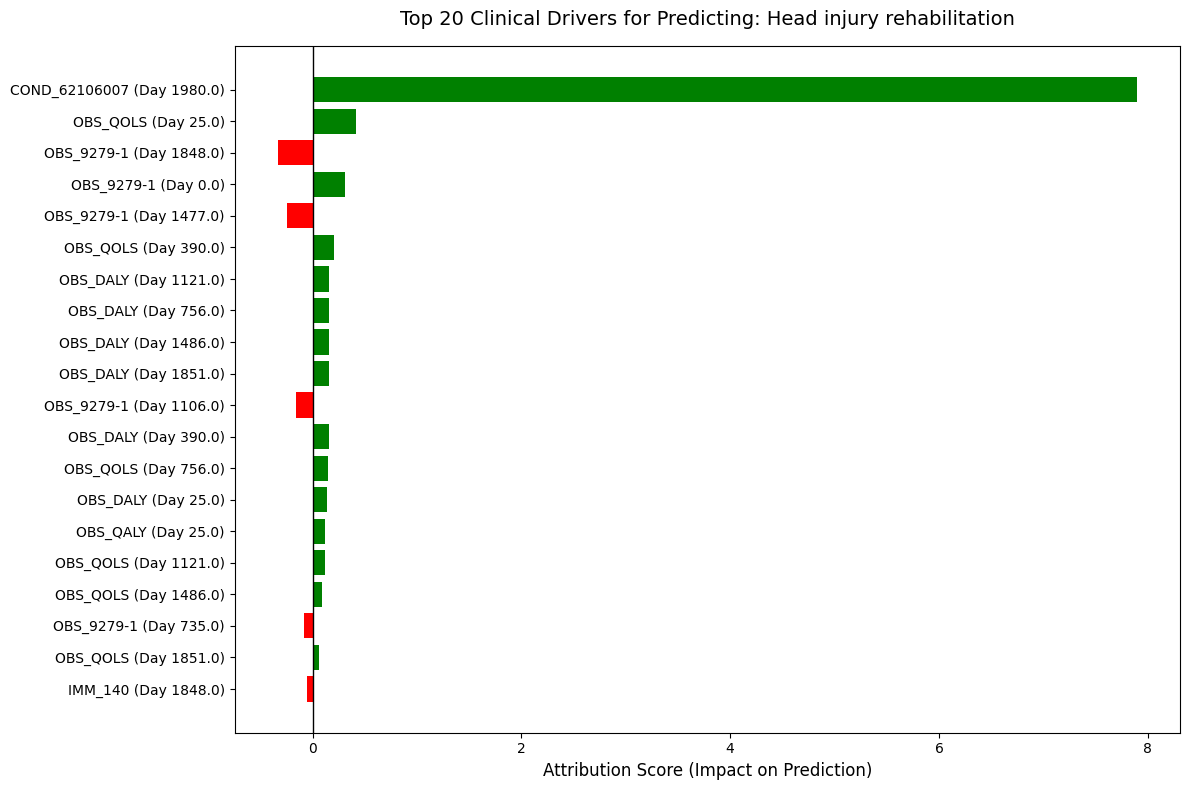

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Reverse the token vocabulary to map indices back to EVENT_CODE strings
idx_to_token = {v: k for k, v in tokenizer.token_vocab.items()}

# 2. Extract the string representations and scores
token_strs = [idx_to_token.get(t, f"<UNK_{t}>") for t in tokens]
scores = token_attributions.cpu().detach().numpy()
time_days = times

# 3. Select the top 20 most impactful events by absolute attribution score to avoid a cluttered plot
abs_scores = np.abs(scores)
top_indices = np.argsort(abs_scores)[-20:]

# 4. Prepare labels combining the event code and the day it occurred
top_labels = [f"{token_strs[i]} (Day {time_days[i]})" for i in top_indices]
top_scores = scores[top_indices]

# 5. Plot the attributions
plt.figure(figsize=(12, 8))
colors = ['green' if s > 0 else 'red' for s in top_scores]
plt.barh(range(len(top_scores)), top_scores, color=colors)
plt.yticks(range(len(top_scores)), top_labels, fontsize=10)
plt.xlabel("Attribution Score (Impact on Prediction)", fontsize=12)

# Get the target description
idx_to_class = {v: k for k, v in tokenizer.target_vocab.items()}
target_code = idx_to_class.get(target, str(target))
target_desc = careplan_mapping.get(target_code, target_code)

plt.title(f"Top 20 Clinical Drivers for Predicting: {target_desc}", fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

### Clinical Interpretability Summary

Based on the attribution scores calculated by Integrated Gradients, we can interpret the key clinical drivers for predicting the patient's next care plan:

* **Primary Positive Driver:** The most significant factor driving the model's prediction is the condition `COND_62106007` (Concussion with no loss of consciousness) recorded on Day 1980. This makes clinical sense as it directly precedes and strongly correlates with a Head Injury Rehabilitation care plan.
* **Secondary Positive Drivers:** Various observation scores (like QOLS, DALY, and specific LOINC codes) recorded across different days (e.g., Day 25, 1848, 1486) also positively pushed the model towards this specific prediction.
* **Negative Drivers:** Certain observations at specific timepoints (e.g., OBS_9279-1 on Day 1477) had negative attribution scores, indicating they provided evidence against this specific care plan, though they were outweighed by the more recent, highly relevant condition code.

This level of transparency helps clinicians trust the model by ensuring its reasoning aligns with clinical knowledge, specifically identifying the acute condition that precipitated the need for the rehabilitation plan.